In [1]:
import pandas as pd 

data = pd.read_csv("testcpns3.csv")
data.head() 

,toefl,ipk,pengalaman_kerja,diterima
0,780,4.00,3,1
1,750,3.09,4,1
2,690,3.03,3,0
3,710,3.07,5,1
4,680,3.09,4,0


In [2]:
# Load the testcpns dataset
cpns_data = pd.read_csv('testcpns3.csv')

# Display a summary of the data
print(cpns_data.describe())

            toefl        ipk  pengalaman_kerja   diterima
count   40.000000  40.000000         40.000000  40.000000
mean   654.000000   2.694500          3.425000   0.475000
std     61.427464   0.653899          1.737778   0.505736
min    540.000000   1.070000          1.000000   0.000000
25%    607.500000   2.070000          2.000000   0.000000
50%    660.000000   3.030000          4.000000   0.000000
75%    690.000000   3.070000          5.000000   1.000000
max    780.000000   4.000000          6.000000   1.000000


Mayoritas kandidat memiliki skor TOEFL yang cukup tinggi (di atas 600) dan IPK sekitar 3. Dengan pengalaman kerja rata-rata lebih dari 3 tahun, hampir separuh kandidat berhasil diterima. Data ini menunjukkan bahwa kombinasi skor akademik dan pengalaman kerja yang baik berpotensi meningkatkan peluang diterima.

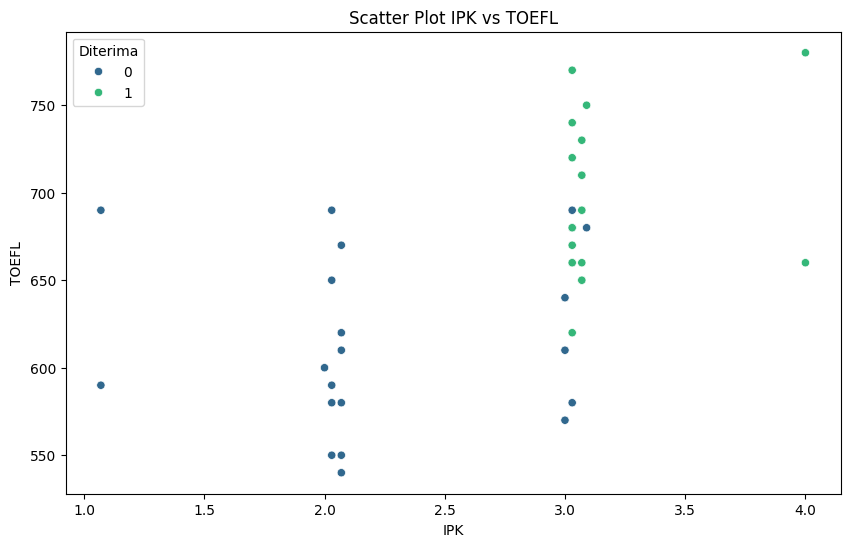

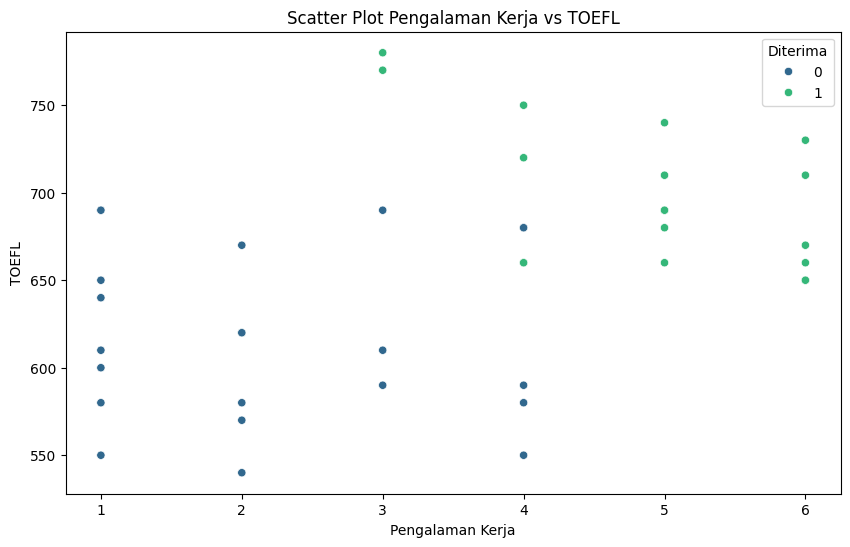

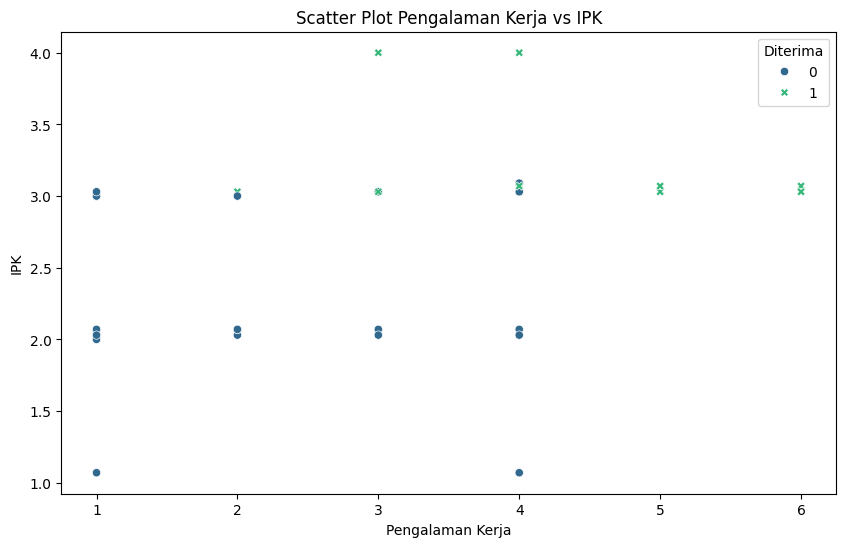

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Scatter plot untuk IPK vs TOEFL
plt.figure(figsize=(10, 6))
sns.scatterplot(data=cpns_data, x='ipk', y='toefl', hue='diterima', palette='viridis')
plt.title('Scatter Plot IPK vs TOEFL')
plt.xlabel('IPK')
plt.ylabel('TOEFL')
plt.legend(title='Diterima')
plt.show()

# Plot kedua: Pengalaman Kerja vs TOEFL
plt.figure(figsize=(10, 6))
sns.scatterplot(data=cpns_data, x='pengalaman_kerja', y='toefl', hue='diterima', palette='viridis')
plt.title('Scatter Plot Pengalaman Kerja vs TOEFL')
plt.xlabel('Pengalaman Kerja')
plt.ylabel('TOEFL')
plt.legend(title='Diterima')
plt.show()

# Plot ketiga: Pengalaman Kerja vs IPK
plt.figure(figsize=(10, 6))
sns.scatterplot(data=cpns_data, x='pengalaman_kerja', y='ipk', hue='diterima', style='diterima', palette='viridis')
plt.title('Scatter Plot Pengalaman Kerja vs IPK')
plt.xlabel('Pengalaman Kerja')
plt.ylabel('IPK')
plt.legend(title='Diterima')
plt.show()

Dari ketiga scatter plot diatas kita bisa tarik kesimpulan, yaitu : 

1. **Scatter Plot IPK vs TOEFL**:
   - Kandidat yang diterima (label 1) cenderung memiliki nilai TOEFL lebih tinggi (di atas 600) dan IPK mendekati atau di atas 3.0.
   - Kandidat yang tidak diterima (label 0) tersebar di IPK lebih rendah dari 3.0 dan TOEFL lebih rendah dari 700.

2. **Scatter Plot Pengalaman Kerja vs TOEFL**:
   - Kandidat yang diterima (label 1) lebih sering memiliki pengalaman kerja di atas 3 tahun dan nilai TOEFL lebih tinggi dari 600.
   - Kandidat yang tidak diterima (label 0) tersebar di berbagai level pengalaman kerja, tetapi lebih sering terlihat pada TOEFL yang lebih rendah.

3. **Scatter Plot Pengalaman Kerja vs IPK**:
   - Kandidat yang diterima (label 1) cenderung memiliki kombinasi IPK di atas 3.0 dengan pengalaman kerja lebih dari 3 tahun.
   - Kandidat yang tidak diterima (label 0) lebih sering memiliki IPK lebih rendah dari 3.0, meskipun pengalaman kerja mereka bervariasi.

Jadi, kombinasi IPK tinggi (di atas 3.0), nilai TOEFL tinggi (di atas 600), dan pengalaman kerja yang cukup (lebih dari 3 tahun) tampaknya menjadi faktor yang dominan dalam mempengaruhi penerimaan kandidat. Kandidat dengan kombinasi nilai yang lebih rendah lebih cenderung tidak diterima. Hal ini menunjukkan bahwa peningkatan di salah satu aspek, terutama TOEFL atau IPK, dapat meningkatkan peluang diterima.

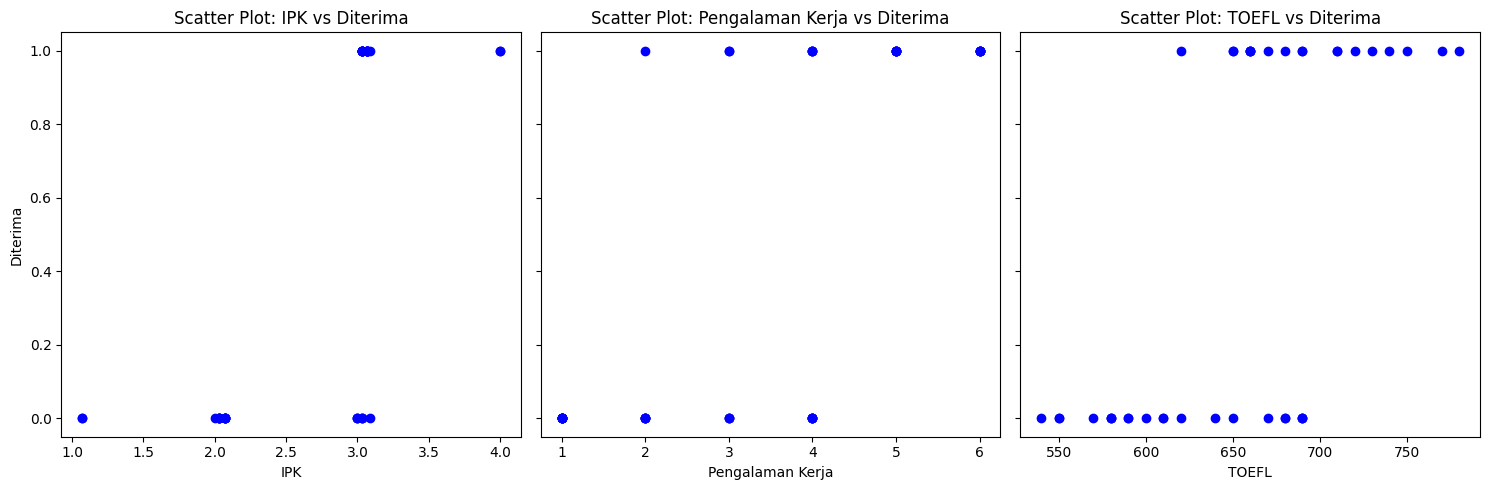

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
cpns_data = pd.read_csv('testcpns3.csv')

# Buat figure untuk beberapa plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Plot scatter untuk masing-masing variabel
axes[0].scatter(cpns_data['ipk'], cpns_data['diterima'], color='blue')
axes[0].set_xlabel('IPK')
axes[0].set_ylabel('Diterima')
axes[0].set_title('Scatter Plot: IPK vs Diterima')

axes[1].scatter(cpns_data['pengalaman_kerja'], cpns_data['diterima'], color='blue')
axes[1].set_xlabel('Pengalaman Kerja')
axes[1].set_title('Scatter Plot: Pengalaman Kerja vs Diterima')

axes[2].scatter(cpns_data['toefl'], cpns_data['diterima'], color='blue')
axes[2].set_xlabel('TOEFL')
axes[2].set_title('Scatter Plot: TOEFL vs Diterima')

# Sesuaikan layout
plt.tight_layout()
plt.show()

Kesimpulan secara keseluruhan, hasil ini menunjukkan bahwa faktor IPK, pengalaman kerja, dan skor TOEFL memiliki pengaruh besar terhadap peluang diterimanya kandidat. Kandidat yang memiliki nilai lebih tinggi dalam ketiga aspek ini cenderung memiliki peluang lebih besar untuk diterima. Sebaliknya, nilai yang rendah pada salah satu atau lebih dari ketiga aspek ini meningkatkan risiko tidak diterima. Kombinasi dari ketiga faktor ini sangat menentukan dalam proses seleksi.

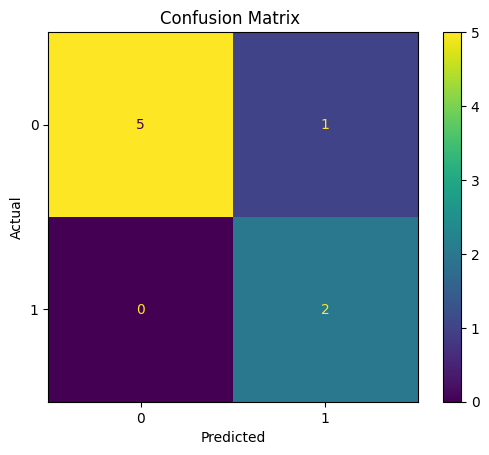

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Preparing the data for prediction
X = data[["ipk", "pengalaman_kerja", "toefl"]]
y = data["diterima"]

# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training the Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Making predictions
y_pred = model.predict(X_test)

# Computing confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Calculating accuracy
accuracy = accuracy_score(y_test, y_pred)

# Displaying the confusion matrix
cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
cmd.plot(cmap='viridis')  # Use 'plasma' color palette
plt.title("Confusion Matrix ")  # Add accuracy to the title
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Jadi kalau menurut saya, saya bisa menarik kesimpulan bahwa hasil confusion matrix menunjukkan bahwa model sudah cukup baik dalam memprediksi data. Sebanyak 5 kandidat yang tidak diterima berhasil diprediksi dengan benar, sementara 2 kandidat yang diterima juga diprediksi dengan tepat. Namun, ada 1 kandidat yang seharusnya tidak diterima malah diprediksi diterima. Secara keseluruhan, model ini lebih akurat dalam memprediksi kandidat yang tidak diterima dibandingkan dengan yang diterima.

In [19]:
import pandas as pd

# Membuat dataset dengan memasukkan data untuk indeks 18
data = pd.DataFrame({
    "toefl": [550, 620, 670, 680, 610, 650, 690, 540, 660, 580, 650, 600],
    "ipk": ["02.03", "03.03", "03.03", "03.09", "02.07", "03.07", "03.07", "02.07", "03.03", "02.03", "02.03", "02.09"],
    "pengalaman_kerja": [4, 2, 6, 4, 3, 6, 5, 5, 2, 2, 1, 3],
    "diterima": [0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1],
})

# Menyesuaikan indeks dengan jumlah baris (memasukkan indeks 18
data.index = [22, 20, 25, 4, 10, 15, 28, 11, 18, 29, 27, 35]

# Menampilkan dataset
print(data)

    toefl    ipk  pengalaman_kerja  diterima
22    550  02.03                 4         0
20    620  03.03                 2         0
25    670  03.03                 6         1
4     680  03.09                 4         1
10    610  02.07                 3         0
15    650  03.07                 6         1
28    690  03.07                 5         1
11    540  02.07                 5         1
18    660  03.03                 2         1
29    580  02.03                 2         0
27    650  02.03                 1         0
35    600  02.09                 3         1


Berdasarkan data tersebut:

1. Kandidat dengan nilai *TOEFL* dan *IPK* yang lebih tinggi cenderung memiliki status diterima (*diterima = 1*).
2. Pengalaman kerja kandidat beragam, mulai dari 1 hingga 6 tahun, yang juga berkontribusi terhadap keputusan diterima atau tidaknya kandidat.
3. Sebagian besar kandidat yang tidak diterima memiliki nilai TOEFL lebih rendah dan *IPK* di bawah rata-rata.

Jadi, kesimpulan sederhana dari data ini adalah bahwa kombinasi nilai TOEFL, IPK, dan pengalaman kerja memberikan pengaruh pada peluang diterima, meskipun keputusan akhir tetap bergantung pada parameter tertentu yang mungkin tidak tercantum dalam dataset ini.

In [13]:
data.to_csv('Data Kriteria.csv', index=False)

In [14]:
import pandas as pd

# Membuat DataFrame dari tabel yang diberikan
data_dict = {
    "toefl": [590, 740, 680, 610, 710],
    "ipk": [2, 3.07, 3.03, 2.03, 3],
    "pengalaman_kerja": [3, 4, 6, 1, 5]
}

df = pd.DataFrame(data_dict)

# Menyimpan DataFrame ke file CSV
df.to_csv("Data Calon Pekerja.csv", index=False)

In [15]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

# Membaca file CSV model data dan raw data
model_data = pd.read_csv("Data Kriteria.csv")
raw_data = pd.read_csv("Data Calon Pekerja.csv")

# Menyiapkan data model
X_model = model_data[["toefl", "ipk", "pengalaman_kerja"]]
y_model = model_data["diterima"]

# Melatih model Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_model, y_model)

# Memprediksi data pelamar baru
X_raw = raw_data[["toefl", "ipk", "pengalaman_kerja"]]
predictions = log_reg.predict(X_raw)

# Menambahkan prediksi ke data raw
raw_data["prediction_diterima"] = predictions

# Menampilkan hasil
print(raw_data)

   toefl   ipk  pengalaman_kerja  prediction_diterima
0    590  2.00                 3                    0
1    740  3.07                 4                    1
2    680  3.03                 6                    1
3    610  2.03                 1                    0
4    710  3.00                 5                    1


Dengan menggunakan model Logistic Regression kita dapat menarik kesimpulan sebagai berikut :

1. Kandidat dengan nilai *TOEFL* rendah (contohnya 590) dan *IPK* yang tidak terlalu tinggi (2.00) diprediksi tidak diterima.
2. Sebaliknya, kandidat dengan nilai *TOEFL* tinggi (contohnya 740 dan 710) serta *IPK* yang cukup baik diprediksi diterima.
3. Pengalaman kerja juga menjadi salah satu faktor penting. Kandidat dengan pengalaman kerja lebih lama memiliki kecenderungan untuk diterima.

Model ini menunjukkan bahwa kombinasi dari *TOEFL*, *IPK*, dan pengalaman kerja memainkan peran signifikan dalam menentukan apakah seorang kandidat akan diterima atau tidak. 